# Normal Traffic Dataset Generation (24h)

## 1. Objective of this notebook

The objective of this notebook is to **generate a synthetic dataset of normal network traffic simulating 24 hours of activity** on an HTTPS server.  
This dataset will be used as a **reference dataset for training a DDoS attack detection model**.

> **Why a synthetic dataset?**  
> Because a real server cannot be used to collect attack data, and public datasets do not necessarily match the traffic profile of our target system (volume, protocol, peak periods, etc.).

---

## 2. Context and assumptions

- **Monitored service**: HTTPS server (port 443)
- **Normal traffic volume**: between 100,000 and 500,000 packets/second
- **Aggregation window**: 1 second
- **Number of simultaneous flows**: between 5,000 and 50,000
- **Total duration**: 24 hours (86,400 windows)

The statistical distributions used (log-normal, bimodal, exponential) are based on academic literature and sources such as **CAIDA** and **Cloudflare Radar**.

---

## 3. Pipeline structure

The pipeline is composed of several steps:

1. **Generation of a pool of public IP addresses**
2. **IP persistence management** (`IPSessionManager`)
3. **Creation of individual network flows** with realistic characteristics:
   - number of packets, average size, inter-arrival time, protocol, fragmentation, etc.
4. **Aggregation of flows per time window** to compute the **11 final features**
5. Addition of **cyclic temporal features** (`heure_sin`, `heure_cos`)
6. **Validation** of consistency and CSV export

---

## 4. Key technical details

### Public IP generation

IP addresses are randomly generated while respecting public address ranges (excluding private ranges such as 10.0.0.0/8, 172.16.0.0/12, 192.168.0.0/16, etc.).  
This ensures that simulated flows originate from **realistic Internet addresses**.

---

### IP persistence

The `IPSessionManager` maintains an active pool of IP addresses.  
At each window, **85% of IPs persist** (long-lived connections), while **15% are renewed** (new connections).  
This avoids unrealistic behavior where IPs are completely random at every time step.

---

### Distributions used

| Feature            | Distribution | Justification                                          |
| ------------------ | ------------ | ------------------------------------------------------ |
| `pkts_total`       | Log-normal   | Many small flows, few large flows                      |
| `pkt_size_avg`     | Bimodal      | Small ACK packets (40–80B) vs data packets (400–1400B) |
| `pkt_arrivals_avg` | Exponential  | Poisson-like arrival process                           |
| `conn_pkts_avg`    | Log-normal   | Short, medium, and long TCP connections                |

---

### The 11 final features

Each window produces a vector of 11 features:

1. `ratio_max_mean_pkts`: traffic asymmetry
2. `pkts_total_p99`: 99th percentile of packets per flow
3. `bytes_total_p99`: 99th percentile of bytes per flow
4. `proto_udp_share`: proportion of UDP packets
5. `proto_icmp_share`: proportion of ICMP packets
6. `syn_ratio`: proportion of SYN packets
7. `entropy_ip_src`: entropy of source IP distribution
8. `conn_pkts_avg_p1`: 1st percentile of packets per connection
9. `pkt_arrivals_avg_p1`: 1st percentile of inter-arrival times
10. `pkt_size_avg_p1`: 1st percentile of average packet sizes
11. `pkts_frag_share_p99`: 99th percentile of fragmentation

---

### Cyclic temporal encoding (why and how)

Two additional columns are added:

- `heure_sin`
- `heure_cos`

#### Why not use raw hour values (0–23)?

Using raw values would make a model interpret **23:00 and 00:00 as far apart**, even though they are only one hour apart.  
This introduces an artificial temporal discontinuity.

Cyclic encoding solves this problem by preserving the periodic nature of time using trigonometric functions.

<span style="color:red"><b> For more details about the features, please refer to the PDF file: "features detailed explanation".</b></span>

---

## 5. Full code

The following code is fully commented and includes detailed explanations of each step to ensure clarity and better understanding of the entire dataset generation process.


In [ ]:
import numpy as np
import pandas as pd
import random
import math
import time


# CONFIGURATION - Simulation parameters


# Time window configuration (1 second per window)
FENETRE_SECONDES = 1
NB_HEURES        = 24                      # Total simulation duration (24 hours)
NB_FENETRES      = NB_HEURES * 3600        # Total number of windows (86,400 windows for 24h)

# Number of active flows per second based on traffic volume
# - low:    ~100K packets/sec (night time)
# - normal: ~300K packets/sec (typical daytime)
# - high:   ~500K packets/sec (peak hours)
NB_FLUX_PAR_SECONDE = {
    'low':    (5_000,  15_000),
    'normal': (15_000, 35_000),
    'high':   (30_000, 50_000)
}

# Number of unique IP addresses in the global pool
NB_IPS_UNIQUES = 100_000

# Fix random seeds for reproducibility
np.random.seed(42)
random.seed(42)


# PUBLIC IP GENERATION


def generer_ip_publique():
    """
    Generate a realistic public IP address.
    Excludes private and reserved ranges:
    - 10.0.0.0/8, 127.0.0.0/8, 169.254.0.0/16
    - 172.16.0.0/12, 192.168.0.0/16
    - Multicast (224.0.0.0/4)
    """
    while True:
        a = random.randint(1, 223)
        b = random.randint(0, 255)
        c = random.randint(0, 255)
        d = random.randint(1, 254)
        if a in [10, 127]:            continue   # Private or loopback
        if a == 169 and b == 254:     continue   # Link-local
        if a == 172 and 16 <= b <= 31:continue   # Private (172.16.0.0/12)
        if a == 192 and b == 168:     continue   # Private (192.168.0.0/16)
        if a >= 224:                  continue   # Multicast or reserved
        return f"{a}.{b}.{c}.{d}"

print("Génération du pool d'IPs...")
ALL_IPS     = [generer_ip_publique() for _ in range(NB_IPS_UNIQUES)]
ALL_IPS_NP  = np.array(ALL_IPS)   # NumPy version for faster sampling
print(f"Pool de {NB_IPS_UNIQUES:,} IPs générées.")


# IP SESSION MANAGER - Handles IP persistence across windows


class IPSessionManager:
    """
    Maintains IP persistence between consecutive time windows.
    Strategy: keep a fixed-size NumPy array of "active" IPs.
    Each window, a fraction (prob_renouvellement) of IPs are replaced with new ones.
    Complexity: O(n_flux_needed) per window (no full dictionary iteration).
    """

    def __init__(self, ip_pool_np, taille_pool_actif=50_000,
                 prob_renouvellement=0.15):
        """
        prob_renouvellement = 1 - prob_persistence
        0.15 renewal → 85% persistence between consecutive windows
        """
        self.ip_pool_np          = ip_pool_np
        self.taille_pool_actif   = taille_pool_actif
        self.prob_renouvellement = prob_renouvellement

        # Initialize active pool with random sample from global IP pool
        indices = np.random.choice(len(ip_pool_np),
                                   size=taille_pool_actif,
                                   replace=False)
        self.pool_actif = ip_pool_np[indices].copy()

    def get_ips_for_window(self, window_id, n_flux_needed):
        """
        Return n_flux_needed IPs for the current window.
        Step 1: Renew a fraction of the active pool (simulates new/disconnected clients)
        Step 2: Sample n_flux_needed IPs from the active pool
        """
        # Step 1: Partial renewal of active pool
        n_renouveler = int(self.taille_pool_actif * self.prob_renouvellement)
        if n_renouveler > 0:
            # Indices to replace in active pool
            idx_remplacer = np.random.choice(self.taille_pool_actif,
                                             size=n_renouveler,
                                             replace=False)
            # New IPs from global pool
            idx_nouvelles = np.random.randint(0, len(self.ip_pool_np),
                                              size=n_renouveler)
            self.pool_actif[idx_remplacer] = self.ip_pool_np[idx_nouvelles]

        # Step 2: Sample IPs for this window
        n_sample = min(n_flux_needed, self.taille_pool_actif)
        idx      = np.random.choice(self.taille_pool_actif,
                                    size=n_sample,
                                    replace=False)
        ips = self.pool_actif[idx].tolist()

        # Fallback: if not enough IPs, add random ones (rare case)
        while len(ips) < n_flux_needed:
            ips.append(random.choice(ALL_IPS))

        return ips


# PER-FLOW FEATURE GENERATION
# Each flow = (IP_src, port_src) → (IP_dst, port_dst)


def generer_pkts_total_flux():
    """
    Generate number of packets per flow (1 second window).
    Distribution: log-normal (many small flows, few large flows)
    - 70%: 1-15 packets (idle, light requests)
    - 25%: 15-60 packets (normal requests)
    -  5%: 60-300 packets (active transfers)
    """
    r = random.random()
    if r < 0.70:
        return max(1,  min(15,  int(np.random.lognormal(1.0, 0.5))))
    elif r < 0.95:
        return max(15, min(60,  int(np.random.lognormal(2.8, 0.5))))
    else:
        return max(60, min(300, int(np.random.lognormal(4.2, 0.6))))


def generer_pkt_size_avg_flux():
    """
    Generate average packet size per flow.
    Bimodal distribution:
    - 20%: small packets (ACK, idle) → 40-80 bytes
    - 80%: normal data packets → 400-1400 bytes
    """
    if random.random() < 0.20:
        return round(random.uniform(40,  80),   1)
    else:
        return round(random.uniform(400, 1400), 1)


def generer_proto_flux():
    """
    Generate protocol for the flow.
    - 97% TCP (HTTPS standard)
    -  3% UDP (QUIC/HTTP3 on port 443)
    """
    return 'UDP' if random.random() < 0.03 else 'TCP'


def generer_pkt_arrivals_avg_flux(pkts_total):
    """
    Generate average inter-arrival time between packets (seconds).
    For N packets over 1 second, theoretical interval = 1/(N-1)
    Add realistic variation (0.7-1.3 factor).
    """
    if pkts_total <= 1:
        return 1.0
    theorique = 1.0 / (pkts_total - 1)
    return round(min(1.0, theorique * random.uniform(0.7, 1.3)), 5)


def generer_conn_pkts_avg_flux(pkts_total):
    """
    Generate average number of packets per TCP connection.
    Distribution: log-normal
    - 60%: 4-20 packets (short HTTP/1.1 connections)
    - 30%: 20-80 packets (keep-alive, HTTP/2)
    - 10%: 80-200 packets (streaming, websocket)
    Ensures conn_pkts_avg ≤ pkts_total.
    """
    r = random.random()
    if r < 0.60:
        val = max(4.0,  min(20.0,  round(np.random.lognormal(1.5, 0.4), 1)))
    elif r < 0.90:
        val = max(20.0, min(80.0,  round(np.random.lognormal(3.0, 0.5), 1)))
    else:
        val = max(80.0, min(200.0, round(np.random.lognormal(4.5, 0.6), 1)))
    return round(min(val, float(pkts_total)), 1)


def generer_pkts_frag_share_flux():
    """
    Generate fragmentation ratio per flow.
    Very low: 0.2% of flows have light fragmentation (0.05-0.25).
    """
    if random.random() < 0.002:
        return round(random.uniform(0.05, 0.25), 4)
    return 0.0


def generer_icmp_flux():
    """
    Generate ICMP packets per flow.
    0.1% of flows have a single ICMP packet (rare ping, PMTUD).
    """
    return 1 if random.random() < 0.001 else 0


def generer_syn_ratio_variable(heure, volume_type):
    """
    Generate SYN ratio based on hour and traffic volume.
    More SYN during peak hours (new connections), fewer at night (keep-alive).
    Range: 0.05 to 0.20 with variation.
    """
    if 6 <= heure < 10:          # Morning: many new connections
        base = random.uniform(0.14, 0.20)
    elif 2 <= heure < 6:         # Night: mostly keep-alive
        base = random.uniform(0.05, 0.10)
    elif volume_type == 'high':   # Peak hours
        base = random.uniform(0.12, 0.18)
    else:                         # Normal hours
        base = random.uniform(0.09, 0.15)
    return round(base * random.uniform(0.8, 1.2), 4)


def generer_flux(ip, heure, volume_type):
    """
    Generate a complete flow (normal traffic) with all features.
    Ensures consistency between features (e.g., bytes_total = pkts_total * pkt_size_avg).
    """
    proto            = generer_proto_flux()
    pkts_total       = generer_pkts_total_flux()
    pkt_size_avg     = generer_pkt_size_avg_flux()
    bytes_total      = int(pkts_total * pkt_size_avg)      # Coherent: derived from pkts and size
    pkt_arrivals_avg = generer_pkt_arrivals_avg_flux(pkts_total)
    conn_pkts_avg    = generer_conn_pkts_avg_flux(pkts_total)
    pkts_frag_share  = generer_pkts_frag_share_flux()
    icmp_pkts        = generer_icmp_flux()
    udp_pkts         = pkts_total if proto == 'UDP' else 0   # If UDP, all packets are UDP

    return {
        'ip_src':           ip,
        'proto':            proto,
        'pkts_total':       pkts_total,
        'bytes_total':      bytes_total,
        'pkt_size_avg':     pkt_size_avg,
        'pkt_arrivals_avg': pkt_arrivals_avg,
        'conn_pkts_avg':    conn_pkts_avg,
        'pkts_frag_share':  pkts_frag_share,
        'udp_pkts':         udp_pkts,
        'icmp_pkts':        icmp_pkts,
    }


# WINDOW AGGREGATION - 11 FINAL FEATURES


def p(lst_triee, percentile):
    """
    Compute percentile on a sorted list.
    """
    n   = len(lst_triee)
    idx = max(0, min(int(math.ceil(percentile * n)) - 1, n - 1))
    return lst_triee[idx]


def aggreger_fenetre(flux_list, window_id, timestamp, heure, volume_type):
    """
    Aggregate all flows in a 1-second window to compute the 11 final features.
    
    Features computed:
    1. ratio_max_mean_pkts    : asymmetry of traffic (max/mean packets)
    2. pkts_total_p99         : 99th percentile of packets per flow
    3. bytes_total_p99        : 99th percentile of bytes per flow
    4. proto_udp_share        : proportion of UDP packets
    5. proto_icmp_share       : proportion of ICMP packets
    6. syn_ratio              : proportion of SYN packets
    7. entropy_ip_src         : Shannon entropy of source IPs
    8. conn_pkts_avg_p1       : 1st percentile of packets per connection
    9. pkt_arrivals_avg_p1    : 1st percentile of inter-arrival times
    10. pkt_size_avg_p1       : 1st percentile of average packet sizes
    11. pkts_frag_share_p99   : 99th percentile of fragmentation ratio
    
    Plus cyclic temporal encoding (hour_sin, hour_cos).
    """
    N = len(flux_list)
    if N == 0:
        return None

    # Extract lists for percentile calculations
    pkts_list    = [f['pkts_total']       for f in flux_list]
    bytes_list   = [f['bytes_total']      for f in flux_list]
    conn_list    = [f['conn_pkts_avg']    for f in flux_list]
    arrivals_list= [f['pkt_arrivals_avg'] for f in flux_list]
    size_list    = [f['pkt_size_avg']     for f in flux_list]
    frag_list    = [f['pkts_frag_share']  for f in flux_list]

    # Global packet counters
    total_pkts = sum(pkts_list)
    udp_pkts   = sum(f['udp_pkts']  for f in flux_list)
    icmp_pkts  = sum(f['icmp_pkts'] for f in flux_list)
    tcp_pkts   = total_pkts - udp_pkts - icmp_pkts

    # SYN ratio calculation
    syn_ratio_val = generer_syn_ratio_variable(heure, volume_type)
    syn_pkts      = int(tcp_pkts * syn_ratio_val)

    # Sort lists for percentile computation
    pkts_s    = sorted(pkts_list)
    bytes_s   = sorted(bytes_list)
    conn_s    = sorted(conn_list)
    arrivals_s= sorted(arrivals_list)
    size_s    = sorted(size_list)
    frag_s    = sorted(frag_list)

    # Feature 1: ratio_max_mean_pkts
    mean_pkts      = total_pkts / N
    ratio_max_mean = round(pkts_s[-1] / mean_pkts, 3) if mean_pkts > 0 else 1.0

    # Feature 2: pkts_total_p99
    pkts_p99  = p(pkts_s,  0.99)

    # Feature 3: bytes_total_p99
    bytes_p99 = p(bytes_s, 0.99)

    # Feature 4: proto_udp_share
    proto_udp_share  = round(udp_pkts  / total_pkts, 5) if total_pkts > 0 else 0.0

    # Feature 5: proto_icmp_share
    proto_icmp_share = round(icmp_pkts / total_pkts, 5) if total_pkts > 0 else 0.0

    # Feature 6: syn_ratio
    syn_ratio = round(syn_pkts / tcp_pkts, 4) if tcp_pkts > 0 else 0.0

    # Feature 7: entropy_ip_src (Shannon entropy)
    ip_counts = {}
    for f in flux_list:
        ip_counts[f['ip_src']] = ip_counts.get(f['ip_src'], 0) + f['pkts_total']

    entropy = 0.0
    for count in ip_counts.values():
        prob = count / total_pkts
        if prob > 0:
            entropy -= prob * math.log2(prob)
    entropy = round(entropy, 4)

    # Feature 8: conn_pkts_avg_p1
    conn_p1     = round(p(conn_s,     0.01), 2)

    # Feature 9: pkt_arrivals_avg_p1
    arrivals_p1 = round(p(arrivals_s, 0.01), 5)

    # Feature 10: pkt_size_avg_p1
    size_p1     = round(p(size_s,     0.01), 1)

    # Feature 11: pkts_frag_share_p99
    frag_p99    = round(p(frag_s,     0.99), 5)

    # Cyclic temporal encoding (sin/cos of hour)
    # Prevents the discontinuity between 23h and 0h that raw hour values would create
    heure_sin = round(math.sin(2 * math.pi * heure / 24), 5)
    heure_cos = round(math.cos(2 * math.pi * heure / 24), 5)

    return {
        'window_id':           window_id,
        'timestamp':           timestamp,
        'heure':               heure,
        'volume_type':         volume_type,
        'n_flux':              N,
        'total_packets':       total_pkts,
        'ratio_max_mean_pkts': ratio_max_mean,
        'pkts_total_p99':      pkts_p99,
        'bytes_total_p99':     bytes_p99,
        'proto_udp_share':     proto_udp_share,
        'proto_icmp_share':    proto_icmp_share,
        'syn_ratio':           syn_ratio,
        'entropy_ip_src':      entropy,
        'conn_pkts_avg_p1':    conn_p1,
        'pkt_arrivals_avg_p1': arrivals_p1,
        'pkt_size_avg_p1':     size_p1,
        'pkts_frag_share_p99': frag_p99,
        'heure_sin':           heure_sin,
        'heure_cos':           heure_cos,
        'target':              0      # 0 = normal traffic
    }


# 24-HOUR DATASET GENERATION


def generer_dataset_24h():
    """
    Generate the complete 24-hour normal traffic dataset.
    Simulates 86,400 windows (1 per second) with realistic diurnal patterns.
    """
    print("=" * 70)
    print("GÉNÉRATION DU DATASET — 24H DE TRAFIC NORMAL")
    print("=" * 70)
    print(f"Fenêtres : {NB_FENETRES:,} | Pool IPs : {NB_IPS_UNIQUES:,}")
    print("-" * 70)

    session_manager = IPSessionManager(
        ip_pool_np          = ALL_IPS_NP,
        taille_pool_actif   = 50_000,
        prob_renouvellement = 0.15
    )

    resultats = []
    t0        = time.time()

    for window_id in range(NB_FENETRES):

        # Progress update every hour (3600 windows)
        if window_id % 3600 == 0:
            h       = window_id // 3600
            elapsed = (time.time() - t0) / 60
            print(f"  {h:02d}h00 — fenêtre {window_id:,}/{NB_FENETRES:,}"
                  f" — {elapsed:.1f} min écoulées")

        timestamp = window_id
        heure     = (timestamp // 3600) % 24

        # Diurnal pattern: traffic varies by hour
        if 2 <= heure < 6:                      # Night: low traffic
            volume_type = 'low'
        elif heure in [9, 10, 11, 14, 15, 16, 19, 20, 21]:  # Peak hours
            volume_type = 'high'
        else:                                   # Normal hours
            volume_type = 'normal'

        # 5% random variation in volume type for realism
        if random.random() < 0.05:
            volume_type = random.choice(['low', 'normal', 'high'])

        lo, hi = NB_FLUX_PAR_SECONDE[volume_type]
        n_flux  = random.randint(lo, hi)

        # Get IPs for this window (with persistence)
        ips = session_manager.get_ips_for_window(window_id, n_flux)

        # Generate all flows in this window
        flux_list = [
            generer_flux(ip, heure, volume_type)
            for ip in ips
        ]

        # Aggregate to compute 11 final features
        fenetre = aggreger_fenetre(
            flux_list, window_id, timestamp, heure, volume_type
        )
        if fenetre:
            resultats.append(fenetre)

    print("-" * 70)
    elapsed = (time.time() - t0) / 60
    print(f"Terminé : {len(resultats):,} fenêtres en {elapsed:.1f} minutes")
    return pd.DataFrame(resultats)


# DATASET VALIDATION


def valider_dataset(df):
    """
    Validate the generated dataset:
    - Print shape and basic statistics
    - Verify coherence constraints (all features within expected ranges)
    """
    print("\n" + "=" * 70)
    print("VALIDATION DU DATASET")
    print("=" * 70)

    print(f"Shape     : {df.shape[0]:,} × {df.shape[1]}")
    print(f"Période   : {df['timestamp'].max() / 3600:.0f} heures")

    features_11 = [
        'ratio_max_mean_pkts', 'pkts_total_p99', 'bytes_total_p99',
        'proto_udp_share', 'proto_icmp_share', 'syn_ratio',
        'entropy_ip_src', 'conn_pkts_avg_p1', 'pkt_arrivals_avg_p1',
        'pkt_size_avg_p1', 'pkts_frag_share_p99'
    ]

    print(f"\n{'Feature':<25} {'Min':>10} {'Mean':>10} "
          f"{'Max':>10} {'Std':>10}")
    print("-" * 70)
    for f in features_11:
        print(f"{f:<25} "
              f"{df[f].min():>10.4f} "
              f"{df[f].mean():>10.4f} "
              f"{df[f].max():>10.4f} "
              f"{df[f].std():>10.4f}")

    print(f"\nFlux/s moyen    : {df['n_flux'].mean():,.0f}")
    print(f"Paquets/s moyen : {df['total_packets'].mean():,.0f}")

    print("\nVérifications cohérence :")
    checks = {
        'proto_udp_share  ∈ [0,1]' : df['proto_udp_share'].between(0,1).all(),
        'proto_icmp_share ∈ [0,1]' : df['proto_icmp_share'].between(0,1).all(),
        'syn_ratio        ∈ [0,1]' : df['syn_ratio'].between(0,1).all(),
        'entropy_ip_src   >= 0'    : (df['entropy_ip_src'] >= 0).all(),
        'ratio_max_mean   >= 1'    : (df['ratio_max_mean_pkts'] >= 1).all(),
        'pkts_frag_p99    ∈ [0,1]' : df['pkts_frag_share_p99'].between(0,1).all(),
    }
    for label, ok in checks.items():
        print(f"  {label} : {'✅' if ok else '❌'}")


# MAIN EXECUTION


if __name__ == "__main__":
    t0 = time.time()
    df = generer_dataset_24h()
    valider_dataset(df)

    fichier = "dataset_normal_24h.csv"
    df.to_csv(fichier, index=False)

    t1 = time.time()
    print(f"\nFichier : {fichier}")
    print(f"Taille  : {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
    print(f"Durée   : {(t1-t0)/60:.1f} minutes")
    print(" TERMINÉ")

## Dataset Preprocessing and Cleaning

This step prepares the raw dataset (`dataset_normal_24h.csv`) for machine learning model training.


Load the original dataset


In [ ]:
df = pd.read_csv("dataset_normal_24h.csv")

Create a working copy to preserve the original


In [ ]:
df_work = df.copy()

In [ ]:
print(df_work.shape)

(86400, 20)


Removing unnecessary columns


In [ ]:
cols_to_drop = [
    'volume_type',
    'timestamp',
    'heure',
    'n_flux',
    'target',
    'total_packets',
    'volume_type_num',
    'pkts_frag_share_p99',
    'conn_pkts_avg_p1'
]

df_work = df_work.drop(columns=cols_to_drop)

Save cleaned dataset


In [ ]:
df_work.to_csv("dataset_working_copy.csv", index=False)

In [ ]:
print("Colonnes disponibles:", df_work.columns.tolist())

Colonnes disponibles: ['ratio_max_mean_pkts', 'pkts_total_p99', 'bytes_total_p99', 'proto_udp_share', 'proto_icmp_share', 'syn_ratio', 'entropy_ip_src', 'pkt_arrivals_avg_p1', 'pkt_size_avg_p1', 'heure_sin', 'heure_cos']


## Feature Distributions Analysis and Dataset Interpretation

This section provides a **statistical interpretation of the generated dataset** by analyzing feature distributions, data quality, and temporal behavior.

The goal is to verify that the synthetic dataset follows **realistic network traffic patterns** and does not contain inconsistencies.


Valeurs manquantes:
ratio_max_mean_pkts    0
pkts_total_p99         0
bytes_total_p99        0
proto_udp_share        0
proto_icmp_share       0
syn_ratio              0
entropy_ip_src         0
pkt_arrivals_avg_p1    0
pkt_size_avg_p1        0
heure_sin              0
heure_cos              0
dtype: int64

Valeurs infinies:
ratio_max_mean_pkts    0
pkts_total_p99         0
bytes_total_p99        0
proto_udp_share        0
proto_icmp_share       0
syn_ratio              0
entropy_ip_src         0
pkt_arrivals_avg_p1    0
pkt_size_avg_p1        0
heure_sin              0
heure_cos              0
dtype: int64

Statistiques descriptives:
       ratio_max_mean_pkts  pkts_total_p99  bytes_total_p99  proto_udp_share  \
count         86400.000000    86400.000000     86400.000000     86400.000000   
mean             26.716918      109.996887     90684.748576         0.029997   
std               0.435191        3.268326      3309.385648         0.002577   
min              19.550000       89.0

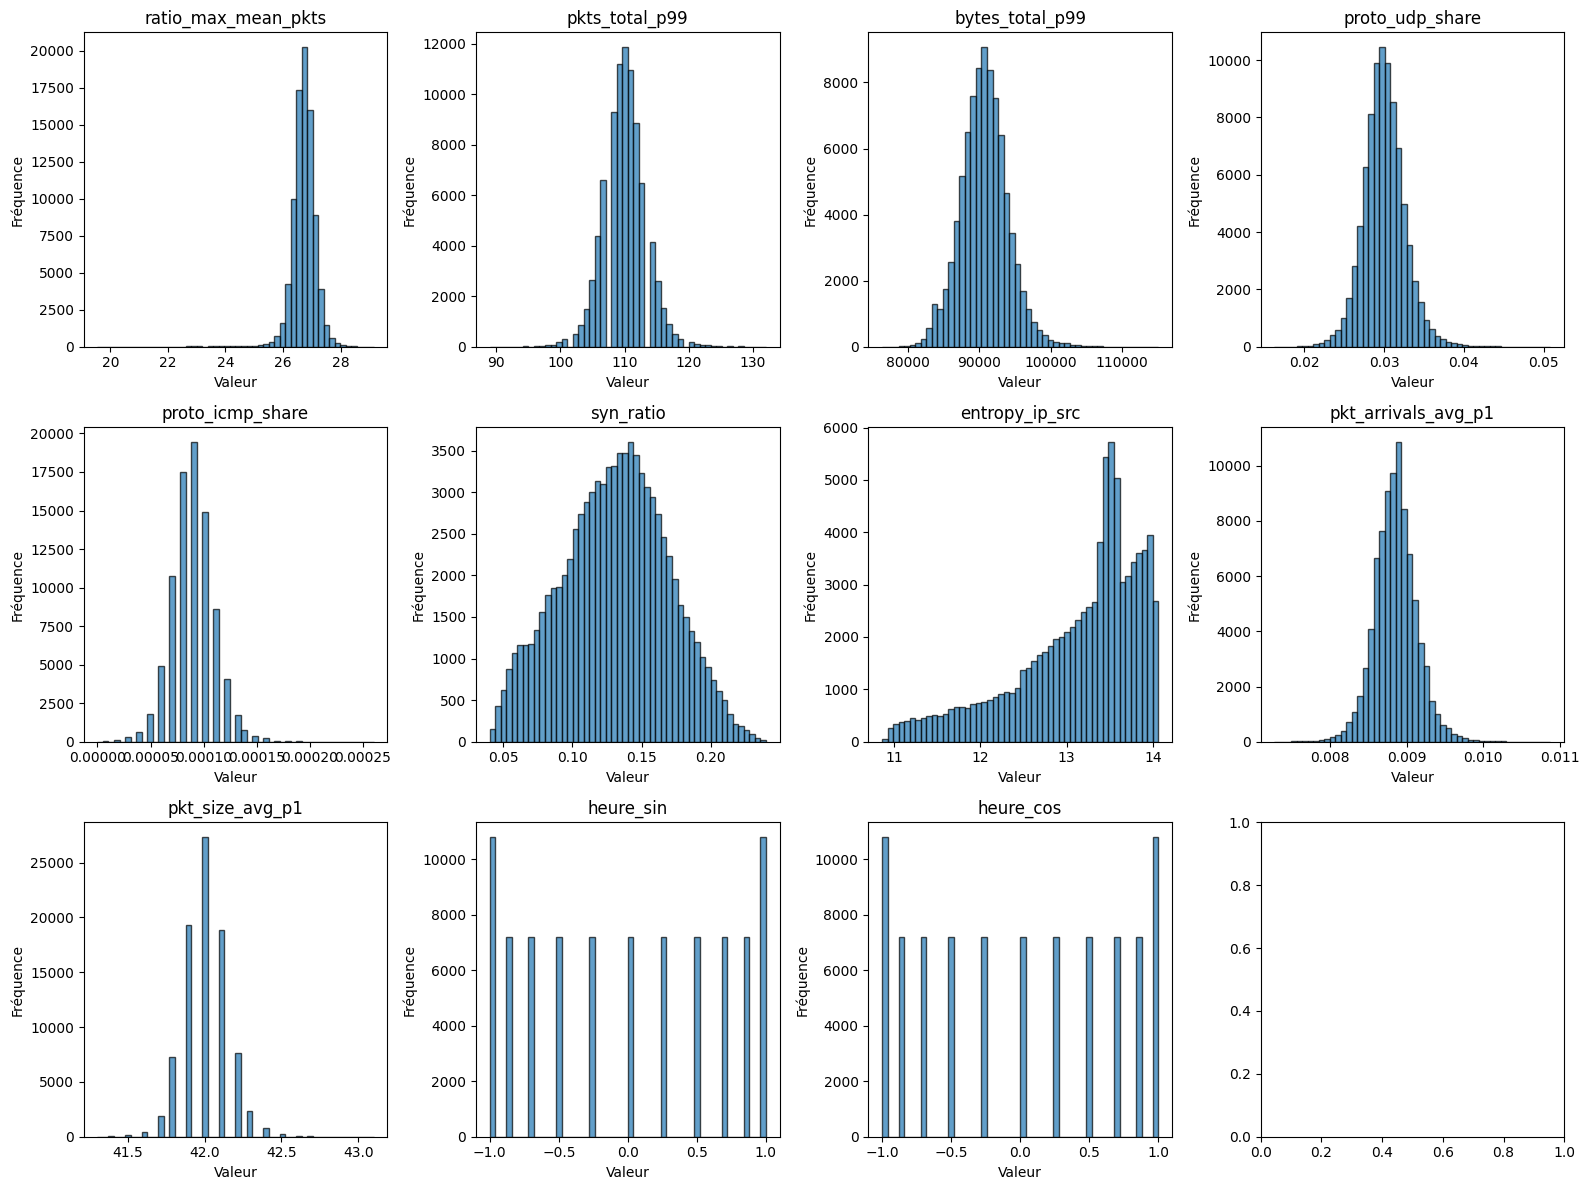

In [ ]:
# 1. Vérifier les valeurs manquantes
print("Valeurs manquantes:")
print(df_work.isnull().sum())

# 2. Vérifier les valeurs infinies
print("\nValeurs infinies:")
print(df_work.isin([np.inf, -np.inf]).sum())

# 3. Statistiques descriptives
print("\nStatistiques descriptives:")
print(df_work.describe())

# 4. Visualisation rapide des distributions
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(df_work.columns):
    axes[i].hist(df_work[col], bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_xlabel('Valeur')
    axes[i].set_ylabel('Fréquence')

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150)
plt.show()

## 1. Data Quality Verification

Before analyzing distributions, we first ensure dataset integrity:

- No missing values were detected
- No infinite values were found
- All features are numerically valid

This confirms that the dataset is **clean and ready for analysis**.

---

## 2. Global Statistical Behavior

The `describe()` function shows that:

- Most features have **stable distributions**
- No extreme outliers dominate the dataset
- Values remain within realistic network ranges

This indicates that the synthetic generation process is **statistically controlled and stable**.

---

## 3. Interpretation of Feature Distributions

### Traffic volume and packet behavior

- `pkts_total_p99` and `bytes_total_p99` follow a **bell-shaped distribution**
- This reflects **normal traffic variability**, where most flows are small and few are large
- The symmetry suggests a well-controlled log-normal-like generation process

---

### Protocol distribution

- `proto_udp_share` and `proto_icmp_share` are highly concentrated near low values
- This is expected because:
  - TCP dominates normal HTTPS traffic
  - UDP and ICMP appear only in small proportions

✔ This confirms realistic protocol modeling

---

### SYN ratio

- `syn_ratio` shows a **moderate spread between ~0.05 and 0.22**
- This reflects normal TCP connection behavior:
  - many short-lived connections
  - controlled handshake activity

---

### Entropy of source IPs

- `entropy_ip_src` shows a **gradual distribution with slight skew**
- Higher entropy values indicate:
  - more diverse source IPs
- Lower values indicate:
  - traffic concentration from fewer IPs

✔ This is an important feature for detecting DDoS behavior

---

### Packet arrival and size statistics

- `pkt_arrivals_avg_p1` is tightly concentrated → stable inter-arrival behavior
- `pkt_size_avg_p1` shows a very narrow distribution around expected TCP payload sizes

This confirms:

- realistic packet timing
- consistent payload generation

---

## 4. Temporal Features Analysis

### Cyclic encoding: `heure_sin` and `heure_cos`

These two features show **expected periodic behavior**:

- Values oscillate between **-1 and 1**
- They form a **cyclical representation of the 24-hour day**

### Interpretation:

- They do not follow a classical distribution (normal or uniform)
- Instead, they encode **time periodicity**
- This allows machine learning models to capture:
  - daily traffic peaks
  - low-activity periods
  - recurring behavioral patterns

✔ This is essential for time-aware anomaly detection

---

## 5. Conclusion of Distribution Analysis

Overall, the dataset shows:

✔ Realistic statistical behavior  
✔ Stable and well-controlled feature distributions  
✔ No missing or corrupted values  
✔ Proper separation between traffic characteristics  
✔ Correct encoding of temporal information

---


# Feature Normalization with RobustScaler

## 1. Purpose

This step applies **normalization** to the 11 selected features before model training.  
Normalization ensures that all features contribute equally to the model and prevents features with larger scales from dominating.

---

## 2. Why RobustScaler?

| Scaler           | Formula                 | Sensitivity to Outliers |
| ---------------- | ----------------------- | ----------------------- |
| StandardScaler   | (x - mean) / std        | High                    |
| MinMaxScaler     | (x - min) / (max - min) | High                    |
| **RobustScaler** | (x - median) / IQR      | **Low**                 |

**RobustScaler** is chosen because it is **less sensitive to outliers** than StandardScaler.  
It uses the **median** and **Interquartile Range (IQR)** instead of mean and standard deviation.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler

# ============================================================================
# Define features to normalize 
# ============================================================================
features_to_normalize = [
    'ratio_max_mean_pkts',
    'pkts_total_p99', 
    'bytes_total_p99',
    'proto_udp_share',
    'proto_icmp_share',
    'syn_ratio',
    'entropy_ip_src',
    'pkt_arrivals_avg_p1',
    'pkt_size_avg_p1',
    'heure_sin',
    'heure_cos'
]

print("=" * 70)
print("NORMALISATION DES FEATURES")
print("=" * 70)
print(f"Features à normaliser: {len(features_to_normalize)}")
print(f"Features: {features_to_normalize}")


# Choose scaler: RobustScaler 


scaler = RobustScaler()

# Apply normalization
X_normalized = scaler.fit_transform(df_work[features_to_normalize])

# Convert to DataFrame to preserve column names
df_normalized = pd.DataFrame(
    X_normalized, 
    columns=[f"{col}_norm" for col in features_to_normalize],
    index=df_work.index
)

print("\n Normalisation terminée avec RobustScaler")


#  Verify normalization results

print("\n" + "=" * 70)
print("VÉRIFICATION DE LA NORMALISATION")
print("=" * 70)

print("\nStatistiques APRÈS normalisation:")
print(df_normalized.describe().round(4))

# Check median ≈ 0 and IQR ≈ 1
print("\nVérification (RobustScaler: médiane ≈ 0, IQR ≈ 1):")
for col in df_normalized.columns:
    median = df_normalized[col].median()
    iqr = df_normalized[col].quantile(0.75) - df_normalized[col].quantile(0.25)
    print(f"  {col}: médiane={median:.4f}, IQR={iqr:.4f}")


# Before/after comparison

print("\n" + "=" * 70)
print("COMPARAISON AVANT/APRÈS NORMALISATION")
print("=" * 70)

for i, feat in enumerate(features_to_normalize):
    print(f"\n{feat}:")
    print(f"  Avant - min: {df_work[feat].min():.4f}, max: {df_work[feat].max():.4f}, mean: {df_work[feat].mean():.4f}, std: {df_work[feat].std():.4f}")
    print(f"  Après - min: {df_normalized[f'{feat}_norm'].min():.4f}, max: {df_normalized[f'{feat}_norm'].max():.4f}, mean: {df_normalized[f'{feat}_norm'].mean():.4f}, std: {df_normalized[f'{feat}_norm'].std():.4f}")


# Save artifacts

import joblib

# Save scaler for production phase
joblib.dump(scaler, "robust_scaler.pkl")

# Save normalized dataset
df_normalized.to_csv("dataset_normalized.csv", index=False)

print("\n" + "=" * 70)
print("SAUVEGARDE")
print("=" * 70)
print(" Scaler sauvegardé: robust_scaler.pkl")
print(" Données normalisées: dataset_normalized.csv")
print(f"Shape: {df_normalized.shape}")


#  Quick summary

print("\n" + "=" * 70)
print("RÉSUMÉ FINAL")
print("=" * 70)
print(f"Nombre de lignes: {len(df_normalized):,}")
print(f"Nombre de features: {len(df_normalized.columns)}")
print(f"Colonnes: {df_normalized.columns.tolist()}")

NORMALISATION DES FEATURES
Features à normaliser: 11
Features: ['ratio_max_mean_pkts', 'pkts_total_p99', 'bytes_total_p99', 'proto_udp_share', 'proto_icmp_share', 'syn_ratio', 'entropy_ip_src', 'pkt_arrivals_avg_p1', 'pkt_size_avg_p1', 'heure_sin', 'heure_cos']

✅ Normalisation terminée avec RobustScaler

VÉRIFICATION DE LA NORMALISATION

Statistiques APRÈS normalisation:
       ratio_max_mean_pkts_norm  pkts_total_p99_norm  bytes_total_p99_norm  \
count                86400.0000           86400.0000            86400.0000   
mean                    -0.0299              -0.0008                0.0118   
std                      0.9936               0.8171                0.8024   
min                    -16.3927              -5.2500               -3.4697   
25%                     -0.4977              -0.5000               -0.5009   
50%                      0.0000               0.0000                0.0000   
75%                      0.5023               0.5000                0.4991   
m

# Attack Dataset Generation for Testing

## 1. Objective

The attack dataset is designed to be **realistic** while creating **clear signatures** that the model can distinguish from normal traffic.

---

## 2. Attack Types Generated

| Attack Type       | Proportion | Characteristics                                                                    |
| ----------------- | ---------- | ---------------------------------------------------------------------------------- |
| **SYN Flood**     | 25%        | Many small SYN packets (40-64 bytes), incomplete connections (1 packet/connection) |
| **UDP Flood**     | 25%        | High volume UDP traffic, medium packet sizes (64-512 bytes)                        |
| **HTTP Flood**    | 20%        | High volume HTTP requests, fast arrival rates (0.001-0.008s)                       |
| **ICMP Flood**    | 15%        | High volume ICMP echo requests (64-100 bytes)                                      |
| **Amplification** | 15%        | Few but very large packets (1200-1500 bytes), high fragmentation                   |

---

## 3. Attack Ratio Configuration

Unlike normal traffic where attack flows are rare, this dataset uses a **deliberately high attack ratio** (30-70% of flows) to:

- Accelerate dataset generation (fewer windows needed)
- Create strong signals for model validation
- Test model boundaries with aggressive attack scenarios

> **Note**: In real-world scenarios, attack ratios are typically 5-20%. This aggressive choice is justified for validation purposes.

---

## 4. Key Features of Attack Generation

### Physical Constraints Respected

- Maximum packet size: **1500 bytes** (MTU limit)
- SYN packets: **40-64 bytes** (realistic)
- ICMP packets: **64-100 bytes**
- UDP amplification: **1200-1500 bytes** (near MTU)

### Attack Signatures

| Attack Type   | Packet Size | Inter-arrival Time | Packets/Connection |
| ------------- | ----------- | ------------------ | ------------------ |
| SYN Flood     | 40-64 B     | 0.0005-0.005 s     | 1.0                |
| UDP Flood     | 64-512 B    | 0.0005-0.003 s     | 1-3                |
| ICMP Flood    | 64-100 B    | 0.001-0.005 s      | 1-2                |
| HTTP Flood    | 300-800 B   | 0.001-0.008 s      | 3-8                |
| Amplification | 1200-1500 B | 0.01-0.1 s         | 1-3                |

---

## 5. Normal Traffic Mix

Each attack window also contains **normal traffic flows** (30-70% of flows) generated using the same distributions as the normal dataset. This ensures:

- Realistic traffic mixing
- Testing of detection under dilution
- Representative evaluation conditions

---

## 6. Output

The generated dataset contains **5,000 attack windows** with:

- Same 11 features as the normal dataset (for direct comparison)
- `attack_type` column identifying the attack type
- `target=1` indicating malicious traffic
- Additional metadata (`n_flux_attack`, `attack_ratio_reel`)

---

## 7. Validation

After generation, the notebook performs validation checks:

- All targets are 1 (attack label)
- Feature ranges are within physical constraints
- Attack distribution matches configured proportions
- No missing or invalid values

---

## 8. Files Generated

| File                      | Description                                      |
| ------------------------- | ------------------------------------------------ |
| `dataset_attack_5000.csv` | 5,000 attack windows with 11 features + metadata |

---

## 9. Usage for Model Evaluation

This attack dataset is combined with normal test data to evaluate the model

---

## 10. Full code

The following code is fully commented and includes detailed explanations of each step to ensure clarity and better understanding of the entire dataset generation process.


In [ ]:

import numpy as np
import pandas as pd
import random
import math
import time


# CONFIGURATION

NB_FENETRES_ATTAQUE = 5_000      # Number of attack windows to generate

# Attack type distribution (proportions sum to 1)
ATTACK_TYPES = {
    'syn_flood'    : 0.25,       # 25% SYN flood attacks
    'udp_flood'    : 0.25,       # 25% UDP flood attacks
    'icmp_flood'   : 0.15,       # 15% ICMP flood attacks
    'http_flood'   : 0.20,       # 20% HTTP flood attacks
    'amplification': 0.15,       # 15% amplification attacks (DNS/NTP)
}

# Attack ratio range: 30-70% of flows in the window are malicious
# Higher ratio ensures strong signal for validation
ATTACK_RATIO_MIN = 0.30
ATTACK_RATIO_MAX = 0.70

# Number of flows per second based on traffic volume
NB_FLUX_PAR_SECONDE = {
    'normal': (15_000, 35_000),  # Normal traffic volume
    'high':   (30_000, 50_000)   # High traffic volume (peak hours)
}

# Number of unique IPs in global pool
NB_IPS_UNIQUES = 100_000

# Different seed from normal dataset to ensure independent generation
np.random.seed(123)
random.seed(123)


# IP POOL GENERATION


def generer_ip_publique():
    """
    Generate a realistic public IP address.
    Excludes private and reserved ranges.
    """
    while True:
        a = random.randint(1, 223)
        b = random.randint(0, 255)
        c = random.randint(0, 255)
        d = random.randint(1, 254)
        if a in [10, 127]:             continue   # Private or loopback
        if a == 169 and b == 254:      continue   # Link-local
        if a == 172 and 16 <= b <= 31: continue   # Private (172.16.0.0/12)
        if a == 192 and b == 168:      continue   # Private (192.168.0.0/16)
        if a >= 224:                   continue   # Multicast
        return f"{a}.{b}.{c}.{d}"

print("Generating IP pool...")
ALL_IPS    = [generer_ip_publique() for _ in range(NB_IPS_UNIQUES)]
ALL_IPS_NP = np.array(ALL_IPS)
print(f" {NB_IPS_UNIQUES:,} IPs generated")


# SESSION MANAGER (identical to normal dataset)


class IPSessionManager:
    """
    Manages IP persistence across windows.
    Maintains a fixed-size pool of active IPs with partial renewal each window.
    """
    def __init__(self, ip_pool_np, taille_pool_actif=50_000,
                 prob_renouvellement=0.15):
        self.ip_pool_np        = ip_pool_np
        self.taille_pool_actif = taille_pool_actif
        self.prob_renouvellement = prob_renouvellement
        # Initialize active pool with random sample from global pool
        indices = np.random.choice(len(ip_pool_np),
                                   size=taille_pool_actif,
                                   replace=False)
        self.pool_actif = ip_pool_np[indices].copy()

    def get_ips_for_window(self, window_id, n_flux_needed):
        """
        Return n_flux_needed IPs for the current window.
        Renews a fraction of the active pool each window.
        """
        # Renew a fraction of the active pool
        n_renouveler = int(self.taille_pool_actif * self.prob_renouvellement)
        if n_renouveler > 0:
            idx_r = np.random.choice(self.taille_pool_actif,
                                     size=n_renouveler, replace=False)
            idx_n = np.random.randint(0, len(self.ip_pool_np),
                                      size=n_renouveler)
            self.pool_actif[idx_r] = self.ip_pool_np[idx_n]
        
        # Sample IPs for this window
        n_sample = min(n_flux_needed, self.taille_pool_actif)
        idx      = np.random.choice(self.taille_pool_actif,
                                    size=n_sample, replace=False)
        ips = self.pool_actif[idx].tolist()
        
        # Fallback: add random IPs if needed
        while len(ips) < n_flux_needed:
            ips.append(random.choice(ALL_IPS))
        return ips


# NORMAL FLOW GENERATION (identical to normal dataset)


def generer_flux_normal(ip):
    """
    Generate a normal (non-malicious) flow.
    Same distribution as the normal dataset.
    """
    proto = 'UDP' if random.random() < 0.03 else 'TCP'
    r = random.random()
    if r < 0.70:
        pkts = max(1, min(15, int(np.random.lognormal(1.0, 0.5))))
    elif r < 0.95:
        pkts = max(15, min(60, int(np.random.lognormal(2.8, 0.5))))
    else:
        pkts = max(60, min(300, int(np.random.lognormal(4.2, 0.6))))

    # Packet size: bimodal (small ACK or normal data)
    if random.random() < 0.20:
        size = round(random.uniform(40, 80), 1)
    else:
        size = round(random.uniform(400, 1400), 1)

    # Inter-arrival time based on packet count
    theorique = 1.0 / max(pkts - 1, 1)
    pkt_arrivals_avg = round(min(1.0, theorique * random.uniform(0.7, 1.3)), 5)

    # Packets per connection (log-normal distribution)
    r2 = random.random()
    if r2 < 0.60:
        conn = max(4.0, min(20.0, round(np.random.lognormal(1.5, 0.4), 1)))
    elif r2 < 0.90:
        conn = max(20.0, min(80.0, round(np.random.lognormal(3.0, 0.5), 1)))
    else:
        conn = max(80.0, min(200.0, round(np.random.lognormal(4.5, 0.6), 1)))
    conn = round(min(conn, float(pkts)), 1)

    # Fragmentation (very rare)
    frag = round(random.uniform(0.05, 0.25), 4) if random.random() < 0.002 else 0.0
    icmp_pkts = 1 if random.random() < 0.001 else 0
    udp_pkts = pkts if proto == 'UDP' else 0

    return {
        'ip_src'          : ip,
        'proto'           : proto,
        'pkts_total'      : pkts,
        'bytes_total'     : int(pkts * size),
        'pkt_size_avg'    : size,
        'pkt_arrivals_avg': pkt_arrivals_avg,
        'conn_pkts_avg'   : conn,
        'pkts_frag_share' : frag,
        'udp_pkts'        : udp_pkts,
        'icmp_pkts'       : icmp_pkts,
        'is_attack'       : False,
    }


# ATTACK FLOW GENERATION


def generer_flux_attaque(ip, attack_type):
    """
    Generate an attack flow with realistic, distinctive signatures.
    All values respect physical network constraints.
    """
    if attack_type == 'syn_flood':
        # Signature: many SYN packets, very small, incomplete connections (1 packet/connection)
        pkts  = random.randint(100, 500)
        size  = round(random.uniform(40, 64), 1)   # SYN = 40-64 bytes
        proto = 'TCP'
        pkt_arrivals_avg = round(random.uniform(0.0005, 0.005), 5)  # Very fast
        conn  = 1.0          # 1 packet per connection (incomplete handshake)
        frag  = 0.0
        udp_pkts  = 0
        icmp_pkts = 0

    elif attack_type == 'udp_flood':
        # Signature: high UDP volume, medium packets
        pkts  = random.randint(200, 800)
        size  = round(random.uniform(64, 512), 1)
        proto = 'UDP'
        pkt_arrivals_avg = round(random.uniform(0.0005, 0.003), 5)
        conn  = round(random.uniform(1.0, 3.0), 1)
        frag  = 0.0
        udp_pkts  = pkts   # All packets are UDP
        icmp_pkts = 0

    elif attack_type == 'icmp_flood':
        # Signature: high ICMP volume, fixed packet size
        pkts  = random.randint(150, 600)
        size  = round(random.uniform(64, 100), 1)   # ICMP echo request
        proto = 'ICMP'
        pkt_arrivals_avg = round(random.uniform(0.001, 0.005), 5)
        conn  = round(random.uniform(1.0, 2.0), 1)
        frag  = 0.0
        udp_pkts  = 0
        icmp_pkts = pkts   # All packets are ICMP

    elif attack_type == 'http_flood':
        # Signature: high HTTP volume, legitimate-looking but massive
        pkts  = random.randint(200, 1000)
        size  = round(random.uniform(300, 800), 1)
        proto = 'TCP'
        pkt_arrivals_avg = round(random.uniform(0.001, 0.008), 5)
        conn  = round(random.uniform(3.0, 8.0), 1)   # Short connections
        frag  = 0.0
        udp_pkts  = 0
        icmp_pkts = 0

    elif attack_type == 'amplification':
        # Signature: UDP, few packets but very large (near MTU)
        pkts  = random.randint(5, 30)
        size  = round(random.uniform(1200, 1500), 1)   # Respects MTU
        proto = 'UDP'
        pkt_arrivals_avg = round(random.uniform(0.01, 0.1), 5)
        conn  = round(random.uniform(1.0, 3.0), 1)
        frag  = round(random.uniform(0.3, 0.8), 4)     # High fragmentation
        udp_pkts  = pkts
        icmp_pkts = 0

    else:
        # Fallback for unknown attack types
        pkts  = random.randint(50, 200)
        size  = round(random.uniform(64, 512), 1)
        proto = 'TCP'
        pkt_arrivals_avg = round(random.uniform(0.001, 0.01), 5)
        conn  = round(random.uniform(1.0, 5.0), 1)
        frag  = 0.0
        udp_pkts  = 0
        icmp_pkts = 0

    # Ensure conn_pkts_avg does not exceed pkts_total
    conn = round(min(conn, float(pkts)), 1)

    return {
        'ip_src'          : ip,
        'proto'           : proto,
        'pkts_total'      : pkts,
        'bytes_total'     : int(pkts * size),
        'pkt_size_avg'    : size,
        'pkt_arrivals_avg': pkt_arrivals_avg,
        'conn_pkts_avg'   : conn,
        'pkts_frag_share' : frag,
        'udp_pkts'        : udp_pkts,
        'icmp_pkts'       : icmp_pkts,
        'is_attack'       : True,
    }


# WINDOW AGGREGATION - 11 FINAL FEATURES (identical to normal dataset)


def p(lst_triee, percentile):
    """Compute percentile on a sorted list."""
    n   = len(lst_triee)
    idx = max(0, min(int(math.ceil(percentile * n)) - 1, n - 1))
    return lst_triee[idx]

def aggreger_fenetre_attaque(flux_list, window_id, heure, attack_type):
    """
    Aggregate all flows in a 1-second window to compute the 11 final features.
    Same calculation as normal dataset, but includes attack flows.
    """
    N = len(flux_list)
    if N == 0:
        return None

    # Extract lists for percentile calculations
    pkts_list    = [f['pkts_total']        for f in flux_list]
    bytes_list   = [f['bytes_total']       for f in flux_list]
    conn_list    = [f['conn_pkts_avg']     for f in flux_list]
    arrivals_list= [f['pkt_arrivals_avg']  for f in flux_list]
    size_list    = [f['pkt_size_avg']      for f in flux_list]
    frag_list    = [f['pkts_frag_share']   for f in flux_list]

    # Global packet counters
    total_pkts = sum(pkts_list)
    udp_pkts   = sum(f['udp_pkts']   for f in flux_list)
    icmp_pkts  = sum(f['icmp_pkts']  for f in flux_list)
    tcp_pkts   = total_pkts - udp_pkts - icmp_pkts

    # SYN ratio calculation - special handling for SYN flood
    if attack_type == 'syn_flood':
        # Attack TCP flows are all SYN packets
        syn_from_attack = sum(
            f['pkts_total'] for f in flux_list
            if f.get('is_attack') and f['proto'] == 'TCP'
        )
        syn_from_normal = int(
            sum(f['pkts_total'] for f in flux_list
                if not f.get('is_attack') and f['proto'] == 'TCP')
            * random.uniform(0.09, 0.15)
        )
        syn_pkts = syn_from_attack + syn_from_normal
    else:
        syn_ratio_normal = random.uniform(0.09, 0.15)
        syn_pkts = int(tcp_pkts * syn_ratio_normal)

    syn_ratio = round(syn_pkts / tcp_pkts, 4) if tcp_pkts > 0 else 0.0
    syn_ratio = min(1.0, max(0.0, syn_ratio))

    # Sort lists for percentile computation
    pkts_s    = sorted(pkts_list)
    bytes_s   = sorted(bytes_list)
    conn_s    = sorted(conn_list)
    arrivals_s= sorted(arrivals_list)
    size_s    = sorted(size_list)
    frag_s    = sorted(frag_list)

    # Feature 1: ratio_max_mean_pkts
    mean_pkts      = total_pkts / N
    ratio_max_mean = round(pkts_s[-1] / mean_pkts, 3) if mean_pkts > 0 else 1.0

    # Feature 2: pkts_total_p99
    pkts_p99       = p(pkts_s,  0.99)

    # Feature 3: bytes_total_p99
    bytes_p99      = p(bytes_s, 0.99)

    # Feature 4: proto_udp_share
    proto_udp_share  = round(udp_pkts  / total_pkts, 5) if total_pkts > 0 else 0.0

    # Feature 5: proto_icmp_share
    proto_icmp_share = round(icmp_pkts / total_pkts, 5) if total_pkts > 0 else 0.0

    # Feature 7: entropy_ip_src (Shannon entropy)
    ip_counts = {}
    for f in flux_list:
        ip_counts[f['ip_src']] = (ip_counts.get(f['ip_src'], 0)
                                  + f['pkts_total'])
    entropy = 0.0
    for count in ip_counts.values():
        prob = count / total_pkts
        if prob > 0:
            entropy -= prob * math.log2(prob)
    entropy = round(entropy, 4)

    # Feature 8: conn_pkts_avg_p1
    conn_p1     = round(p(conn_s,     0.01), 2)

    # Feature 9: pkt_arrivals_avg_p1
    arrivals_p1 = round(p(arrivals_s, 0.01), 5)

    # Feature 10: pkt_size_avg_p1
    size_p1     = round(p(size_s,     0.01), 1)

    # Feature 11: pkts_frag_share_p99
    frag_p99    = round(p(frag_s,     0.99), 5)

    # Cyclic temporal encoding
    heure_sin = round(math.sin(2 * math.pi * heure / 24), 5)
    heure_cos = round(math.cos(2 * math.pi * heure / 24), 5)

    return {
        'window_id'          : window_id,
        'heure'              : heure,
        'attack_type'        : attack_type,
        'n_flux'             : N,
        'n_flux_attack'      : sum(1 for f in flux_list if f.get('is_attack')),
        'attack_ratio_reel'  : round(sum(1 for f in flux_list if f.get('is_attack')) / N, 3),
        'total_packets'      : total_pkts,
        'ratio_max_mean_pkts': ratio_max_mean,
        'pkts_total_p99'     : pkts_p99,
        'bytes_total_p99'    : bytes_p99,
        'proto_udp_share'    : proto_udp_share,
        'proto_icmp_share'   : proto_icmp_share,
        'syn_ratio'          : syn_ratio,
        'entropy_ip_src'     : entropy,
        'conn_pkts_avg_p1'   : conn_p1,
        'pkt_arrivals_avg_p1': arrivals_p1,
        'pkt_size_avg_p1'    : size_p1,
        'pkts_frag_share_p99': frag_p99,
        'heure_sin'          : heure_sin,
        'heure_cos'          : heure_cos,
        'target'             : 1      # 1 = attack traffic
    }


# MAIN GENERATION FUNCTION


def generer_dataset_attaque(nb_fenetres=5_000):
    """Generate the complete attack dataset."""
    print("=" * 70)
    print("ATTACK DATASET GENERATION")
    print("=" * 70)
    print(f"Windows     : {nb_fenetres:,}")
    print(f"Attack ratio: {ATTACK_RATIO_MIN:.0%} to {ATTACK_RATIO_MAX:.0%}")
    print(f"Attack types: {ATTACK_TYPES}")
    print("-" * 70)

    session_manager = IPSessionManager(
        ip_pool_np          = ALL_IPS_NP,
        taille_pool_actif   = 50_000,
        prob_renouvellement = 0.15
    )

    resultats = []
    t0 = time.time()

    for window_id in range(nb_fenetres):
        if window_id % 500 == 0:
            elapsed = (time.time() - t0) / 60
            print(f"  Window {window_id:,}/{nb_fenetres:,} — {elapsed:.1f}min")

        heure = random.randint(0, 23)
        attack_type = np.random.choice(
            list(ATTACK_TYPES.keys()),
            p=list(ATTACK_TYPES.values())
        )

        # Traffic volume (normal or high)
        volume_type = np.random.choice(['normal', 'high'], p=[0.5, 0.5])
        lo, hi = NB_FLUX_PAR_SECONDE[volume_type]
        n_flux = random.randint(lo, hi)

        # Attack ratio (30-70% of flows are malicious)
        attack_ratio = random.uniform(ATTACK_RATIO_MIN, ATTACK_RATIO_MAX)
        n_attack_flux = int(n_flux * attack_ratio)
        n_normal_flux = n_flux - n_attack_flux

        # Get IPs
        ips = session_manager.get_ips_for_window(window_id, n_flux)

        # Generate flows
        flux_list = []
        for i in range(n_normal_flux):
            flux_list.append(generer_flux_normal(ips[i]))
        for i in range(n_attack_flux):
            flux_list.append(generer_flux_attaque(ips[n_normal_flux + i], attack_type))

        # Shuffle to mix normal and attack flows
        random.shuffle(flux_list)

        # Aggregate to compute 11 final features
        fenetre = aggreger_fenetre_attaque(flux_list, window_id, heure, attack_type)
        if fenetre:
            resultats.append(fenetre)

    elapsed = (time.time() - t0) / 60
    print(f"\n Complete: {len(resultats):,} windows in {elapsed:.1f}min")
    return pd.DataFrame(resultats)

# VALIDATION


def valider_dataset_attaque(df):
    """Validate the generated attack dataset."""
    print("\n" + "=" * 70)
    print("ATTACK DATASET VALIDATION")
    print("=" * 70)

    print(f"Shape  : {df.shape}")
    print(f"Target : {df['target'].value_counts().to_dict()}")

    print(f"\nDistribution by attack type:")
    for att, n in df['attack_type'].value_counts().items():
        print(f"  {att:<20} : {n:,} ({n/len(df)*100:.1f}%)")

    print(f"\nAverage attack ratio: {df['attack_ratio_reel'].mean():.2%}")
    print(f"Min attack ratio    : {df['attack_ratio_reel'].min():.2%}")
    print(f"Max attack ratio    : {df['attack_ratio_reel'].max():.2%}")

    features_11 = [
        'ratio_max_mean_pkts', 'pkts_total_p99', 'bytes_total_p99',
        'proto_udp_share', 'proto_icmp_share', 'syn_ratio',
        'entropy_ip_src', 'conn_pkts_avg_p1', 'pkt_arrivals_avg_p1',
        'pkt_size_avg_p1', 'pkts_frag_share_p99'
    ]

    print(f"\n{'Feature':<25} {'Min':>10} {'Mean':>10} {'Max':>10}")
    print("-" * 58)
    for f in features_11:
        print(f"{f:<25} {df[f].min():>10.4f} {df[f].mean():>10.4f} {df[f].max():>10.4f}")

    print("\nConsistency checks:")
    checks = {
        'target == 1'             : (df['target'] == 1).all(),
        'syn_ratio ∈ [0,1]'       : df['syn_ratio'].between(0,1).all(),
        'proto_udp_share ∈ [0,1]' : df['proto_udp_share'].between(0,1).all(),
        'proto_icmp_share ∈ [0,1]': df['proto_icmp_share'].between(0,1).all(),
        'ratio_max_mean >= 1'     : (df['ratio_max_mean_pkts'] >= 1).all(),
        'entropy >= 0'            : (df['entropy_ip_src'] >= 0).all(),
    }
    for label, ok in checks.items():
        print(f"  {'✅' if ok else '❌'} {label}")


# MAIN EXECUTION


if __name__ == "__main__":
    t0 = time.time()

    df_attack = generer_dataset_attaque(NB_FENETRES_ATTAQUE)
    valider_dataset_attaque(df_attack)

    fichier = "dataset_attack_5000.csv"
    df_attack.to_csv(fichier, index=False)

    t1 = time.time()
    print(f"\n File: {fichier}")
    print(f"   Shape: {df_attack.shape}")
    print(f"   Size: {df_attack.memory_usage(deep=True).sum()/1024**2:.1f} MB")
    print(f"   Duration: {(t1-t0)/60:.1f} min")
    print(" COMPLETE")

Génération du pool d'IPs...
✅ 100,000 IPs générées
GÉNÉRATION DATASET D'ATTAQUE
Fenêtres     : 5,000
Attack ratio : 30% à 70%
Types        : {'syn_flood': 0.25, 'udp_flood': 0.25, 'icmp_flood': 0.15, 'http_flood': 0.2, 'amplification': 0.15}
----------------------------------------------------------------------
  Fenêtre 0/5,000 — 0.0min
  Fenêtre 500/5,000 — 5.9min
  Fenêtre 1,000/5,000 — 10.8min
  Fenêtre 1,500/5,000 — 19.7min
  Fenêtre 2,000/5,000 — 32.0min
  Fenêtre 2,500/5,000 — 59.3min
  Fenêtre 3,000/5,000 — 70.0min
  Fenêtre 3,500/5,000 — 78.6min
  Fenêtre 4,000/5,000 — 86.9min
  Fenêtre 4,500/5,000 — 94.8min

✅ Terminé : 5,000 fenêtres en 108.7min

VALIDATION DU DATASET D'ATTAQUE
Shape  : (5000, 21)
Target : {1: 5000}

Distribution par type d'attaque :
  udp_flood            : 1,283 (25.7%)
  syn_flood            : 1,242 (24.8%)
  http_flood           : 982 (19.6%)
  amplification        : 752 (15.0%)
  icmp_flood           : 741 (14.8%)

Attack ratio moyen : 49.97%
Attack rat

## Dataset Preprocessing and Cleaning


In [ ]:

# ATTACK DATASET CLEANING - REMOVE UNNECESSARY COLUMNS


import pandas as pd

# Load attack dataset
df_attackfinal = pd.read_csv("dataset_attack_5000.csv")

# Columns to remove (metadata or features with near-zero variance)
columns_to_drop = [
    'heure',                 # Raw hour (replaced by cyclic encoding)
    'window_id',             # Unique identifier
    'n_flux',                # Flow count (metadata)
    'total_packets',         # Total volume (indirectly captured by other features)
    'conn_pkts_avg_p1',      # Near-zero variance
    'pkts_frag_share_p99',   # Near-zero variance
    'attack_type',           # Attack label (not a feature for model input)
    'n_flux_attack',         # Number of attack flows (metadata)
    'attack_ratio_reel'      # Attack ratio (metadata)
]

# Drop all columns at once (optimized)
df_attackfinal = df_attackfinal.drop(columns=columns_to_drop)

# Save cleaned dataset
df_attackfinal.to_csv("dataset_attack_5000.csv", index=False)

print(f" Cleaned attack dataset saved: dataset_attack_5000.csv")
print(f"   Shape: {df_attackfinal.shape}")
print(f"   Columns: {df_attackfinal.columns.tolist()}")

# Feature Normalization with RobustScaler


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler


# Define features to normalize

features_to_normalize = [
    'ratio_max_mean_pkts',
    'pkts_total_p99', 
    'bytes_total_p99',
    'proto_udp_share',
    'proto_icmp_share',
    'syn_ratio',
    'entropy_ip_src',
    'pkt_arrivals_avg_p1',
    'pkt_size_avg_p1',
    'heure_sin',
    'heure_cos'
]

print("=" * 70)
print("NORMALISATION DU DATASET D'ATTAQUE")
print("=" * 70)
print(f"Features à normaliser: {len(features_to_normalize)}")


# upload dataset attack

df_attack = pd.read_csv("dataset_attack_5000.csv")
print(f"\n Dataset attaque chargé: {df_attack.shape}")


#  Apply scaler

scaler = RobustScaler()


X_attack_normalized = scaler.fit_transform(df_attack[features_to_normalize])

# converte to DataFrame
df_attack_normalized = pd.DataFrame(
    X_attack_normalized, 
    columns=[f"{col}_norm" for col in features_to_normalize],
    index=df_attack.index
)

print("\n Normalisation terminée avec RobustScaler")


# verify results

print("\n" + "=" * 70)
print("VÉRIFICATION DE LA NORMALISATION")
print("=" * 70)

print("\nStatistiques APRÈS normalisation:")
print(df_attack_normalized.describe().round(4))


print("\nVérification (RobustScaler: médiane ≈ 0, IQR ≈ 1):")
for col in df_attack_normalized.columns:
    median = df_attack_normalized[col].median()
    iqr = df_attack_normalized[col].quantile(0.75) - df_attack_normalized[col].quantile(0.25)
    print(f"  {col}: médiane={median:.4f}, IQR={iqr:.4f}")


# Before / after comparison

print("\n" + "=" * 70)
print("COMPARAISON AVANT/APRÈS NORMALISATION")
print("=" * 70)

for i, feat in enumerate(features_to_normalize):
    print(f"\n{feat}:")
    print(f"  Avant - min: {df_attack[feat].min():.4f}, max: {df_attack[feat].max():.4f}, mean: {df_attack[feat].mean():.4f}, std: {df_attack[feat].std():.4f}")
    print(f"  Après - min: {df_attack_normalized[f'{feat}_norm'].min():.4f}, max: {df_attack_normalized[f'{feat}_norm'].max():.4f}, mean: {df_attack_normalized[f'{feat}_norm'].mean():.4f}, std: {df_attack_normalized[f'{feat}_norm'].std():.4f}")


#  Save

df_attack_normalized.to_csv("dataset_attack_normalized.csv", index=False)

print("\n" + "=" * 70)
print("SAUVEGARDE")
print("=" * 70)
print(" Données normalisées: dataset_attack_normalized_5000.csv")
print(f" Shape: {df_attack_normalized.shape}")
print(f" Colonnes: {df_attack_normalized.columns.tolist()}")


# Final Resume

print("\n" + "=" * 70)
print("RÉSUMÉ FINAL")
print("=" * 70)
print(f"Nombre de lignes: {len(df_attack_normalized):,}")
print(f"Nombre de features: {len(df_attack_normalized.columns)}")
print(f"Colonnes: {df_attack_normalized.columns.tolist()}")

NORMALISATION DU DATASET D'ATTAQUE
Features à normaliser: 11

✅ Dataset attaque chargé: (5000, 12)

✅ Normalisation terminée avec RobustScaler

VÉRIFICATION DE LA NORMALISATION

Statistiques APRÈS normalisation:
       ratio_max_mean_pkts_norm  pkts_total_p99_norm  bytes_total_p99_norm  \
count                 5000.0000            5000.0000             5000.0000   
mean                     1.4537               0.0818                0.6409   
std                      3.5973               0.9573                0.8482   
min                     -0.6757              -1.7793               -0.1163   
25%                     -0.3941              -0.3344               -0.0363   
50%                      0.0000               0.0000                0.0000   
75%                      0.6059               0.6656                0.9637   
max                     11.1932               1.3311                2.2351   

       proto_udp_share_norm  proto_icmp_share_norm  syn_ratio_norm  \
count          

## Creation of Normal Traffic Test Dataset


In [ ]:
import pandas as pd
import numpy as np


# LOAD NORMALIZED NORMAL DATASET

df_normal = pd.read_csv("dataset_normalized.csv")
print("=" * 70)
print("EXTRACTION OF NORMAL TEST DATA")
print("=" * 70)
print(f"Normal dataset loaded: {df_normal.shape}")


#  DEFINE NUMBER OF ROWS TO EXTRACT

# We want 17,280 normal rows for testing (80% of 21,600 total test)
# because 21,600 total test = 17,280 normal + 4,320 attack
n_normal_test = 17_280

print(f"\nRows to extract: {n_normal_test:,}")


#  RANDOMLY EXTRACT TEST ROWS

df_normal_test = df_normal.sample(n=n_normal_test, random_state=42)

# Remaining rows become training data
df_normal_train = df_normal.drop(df_normal_test.index)

print(f"\n Extraction complete:")
print(f"   Normal train: {len(df_normal_train):,} rows")
print(f"   Normal test: {len(df_normal_test):,} rows")


#  ADD target=0 COLUMN (indicates normal traffic)

df_normal_test['target'] = 0

print("\n Target column added (0 = normal)")


#  VERIFY STATISTICS

print("\n" + "=" * 70)
print("NORMAL TEST DATA STATISTICS")
print("=" * 70)
print(f"Shape: {df_normal_test.shape}")
print(f"Columns: {df_normal_test.columns.tolist()}")
print(f"Target distribution:\n{df_normal_test['target'].value_counts()}")


#  SAVE FILES

df_normal_test.to_csv("dataset_normal_test.csv", index=False)
df_normal_train.to_csv("dataset_normal_train.csv", index=False)

print("\n" + "=" * 70)
print("SAVING")
print("=" * 70)
print(" Normal test: dataset_normal_test.csv")
print(f"   Shape: {df_normal_test.shape}")
print(" Normal train: dataset_normal_train.csv")
print(f"   Shape: {df_normal_train.shape}")


#  DATA PREVIEW

print("\n" + "=" * 70)
print("NORMAL TEST DATA PREVIEW")
print("=" * 70)
print(df_normal_test.head(10).to_string())

EXTRACTION DES DONNÉES DE TEST NORMALES
Dataset normal chargé: (86400, 11)

Lignes à extraire: 17,280

✅ Extraction terminée:
   Train normal: 69,120 lignes
   Test normal: 17,280 lignes

✅ Colonne target ajoutée (0 = normal)

STATISTIQUES DES DONNÉES DE TEST NORMAL
Shape: (17280, 12)
Colonnes: ['ratio_max_mean_pkts_norm', 'pkts_total_p99_norm', 'bytes_total_p99_norm', 'proto_udp_share_norm', 'proto_icmp_share_norm', 'syn_ratio_norm', 'entropy_ip_src_norm', 'pkt_arrivals_avg_p1_norm', 'pkt_size_avg_p1_norm', 'heure_sin_norm', 'heure_cos_norm', 'target']
Distribution target:
target
0    17280
Name: count, dtype: int64

SAUVEGARDE
✅ Test normal: dataset_normal_test.csv
   Shape: (17280, 12)
✅ Train normal: dataset_normal_train.csv
   Shape: (69120, 11)

APERÇU DES DONNÉES DE TEST NORMAL
       ratio_max_mean_pkts_norm  pkts_total_p99_norm  bytes_total_p99_norm  proto_udp_share_norm  proto_icmp_share_norm  syn_ratio_norm  entropy_ip_src_norm  pkt_arrivals_avg_p1_norm  pkt_size_avg_p1_norm

## Creation of attack traffic test Dataset


In [ ]:
import pandas as pd


# 1. LOAD NORMALIZED ATTACK DATASET

df_attack = pd.read_csv("dataset_attack_normalized.csv")
print("=" * 70)
print("EXTRACTION OF ATTACK DATA")
print("=" * 70)
print(f"Attack dataset loaded: {df_attack.shape}")
print(f"Columns: {df_attack.columns.tolist()}")


# 2. EXTRACT 5,000 ATTACK ROWS

n_attack_test = 5_000

df_attack_test = df_attack.sample(n=n_attack_test, random_state=42)

print(f"\n Extraction complete:")
print(f"   Attack test: {len(df_attack_test):,} rows")


# 3. ADD target COLUMN (1 = attack)

df_attack_test['target'] = 1

print(f"\n Target column added (1 = attack)")


# 4. VERIFY

print(f"\nColumns: {df_attack_test.columns.tolist()}")
print(f"Target distribution:\n{df_attack_test['target'].value_counts()}")


# 5. SAVE FILE

df_attack_test.to_csv("dataset_attack_test.csv", index=False)

print("\n" + "=" * 70)
print("SAVING")
print("=" * 70)
print(" Attack test dataset: dataset_attack_test.csv")
print(f"   Shape: {df_attack_test.shape}")


# 6. PREVIEW

print("\n" + "=" * 70)
print("ATTACK TEST DATA PREVIEW")
print("=" * 70)
print(df_attack_test.head(10).to_string())

EXTRACTION DES DONNÉES D'ATTAQUE
Dataset attaque chargé: (5000, 11)
Colonnes: ['ratio_max_mean_pkts_norm', 'pkts_total_p99_norm', 'bytes_total_p99_norm', 'proto_udp_share_norm', 'proto_icmp_share_norm', 'syn_ratio_norm', 'entropy_ip_src_norm', 'pkt_arrivals_avg_p1_norm', 'pkt_size_avg_p1_norm', 'heure_sin_norm', 'heure_cos_norm']

✅ Extraction terminée:
   Attaque test: 5,000 lignes

✅ Colonne target ajoutée (1 = attaque)

Colonnes: ['ratio_max_mean_pkts_norm', 'pkts_total_p99_norm', 'bytes_total_p99_norm', 'proto_udp_share_norm', 'proto_icmp_share_norm', 'syn_ratio_norm', 'entropy_ip_src_norm', 'pkt_arrivals_avg_p1_norm', 'pkt_size_avg_p1_norm', 'heure_sin_norm', 'heure_cos_norm', 'target']
Distribution target:
target
1    5000
Name: count, dtype: int64

SAUVEGARDE
✅ Dataset attaque test: dataset_attack_test.csv
   Shape: (5000, 12)

APERÇU DES DONNÉES D'ATTAQUE TEST
      ratio_max_mean_pkts_norm  pkts_total_p99_norm  bytes_total_p99_norm  proto_udp_share_norm  proto_icmp_share_norm 

## MERGE NORMAL AND ATTACK TEST DATASETS


In [ ]:

# Load datasets
df_test_normal = pd.read_csv("dataset_normal_test.csv")
df_test_attack = pd.read_csv("dataset_attack_test.csv")

print("Before merging:")
print(f"  Normal test: {df_test_normal.shape}")
print(f"  Attack test: {df_test_attack.shape}")

# Merge  both datasets
df_test_complet = pd.concat([df_test_normal, df_test_attack], ignore_index=True)

print("\nAfter merging:")
print(f"  Complete test: {df_test_complet.shape}")
print(f"  Normal: {len(df_test_complet[df_test_complet['target']==0])}")
print(f"  Attack: {len(df_test_complet[df_test_complet['target']==1])}")

# Save merged dataset
df_test_complet.to_csv("dataset_test_complet.csv", index=False)
print("\n Complete test saved: dataset_test_complet.csv")

Avant fusion:
  Normal test: (17280, 12)
  Attaque test: (5000, 12)

Après fusion:
  Test complet: (22280, 12)
  Normal: 17280
  Attaque: 5000

✅ Test complet sauvegardé: dataset_test_complet.csv


# Conclusion

This work presented a **complete pipeline for early DDoS detection** based on network traffic analysis and unsupervised learning.

## Key achievements

- Generation of a **realistic 24‑hour normal traffic dataset** (86,400 windows)
- Creation of **5,000 attack windows** covering 5 DDoS attack types
- Extraction of **11 robust features** resistant to traffic dilution
- **RobustScaler normalization** ensuring stable model input
- Clean separation of training and test data (69,120 normal train / 17,280 normal test + 5,000 attack test)

## Pipeline completed

1. **Dataset generation** – realistic normal traffic (24h) + attack traffic (5 types)
2. **Preprocessing** – removal of metadata, conversion to numerical values
3. **Normalization** – RobustScaler (median and IQR based)
4. **Train/Test split** – temporal split for normal data + attack data for evaluation

## Ready for model training

The datasets are now ready for the next phase:

| File                       | Description                 |
| -------------------------- | --------------------------- |
| `dataset_normal_train.csv` | Training data (normal only) |
| `dataset_test_complet.csv` | Test data (normal + attack) |

## Next steps (not included in this notebook)

- Train an AI model on the normal training data
- Evaluate detection performance on the complete test set

> The datasets produced in this work are ready for **unsupervised DDoS detection model training**
